In [1]:
import torch
import torch.nn
import matplotlib.pyplot as plt
import os
import sys
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, Dataset, DataLoader, TensorDataset
from torchvision.datasets import CIFAR10
from torchvision.transforms import transforms
from torchsummary import summary
import torch.nn.init as init
from torchvision import datasets

In [2]:
# Thêm thư mục BaseModel vào trong không gian tìm kiếm của hệ thống
sys.path.append(os.path.abspath('../BaseModel/'))

In [3]:
# Thêm Module Base Model
from MLP import *

In [4]:
seed = 42
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
set_seed(seed)

# Chuẩn bị DL Cifa-10

In [5]:
# Thư mục để lưu trữ bộ DL CIFA-10
folder = '../data/'
# Tạo thư mục ../data để lưu trữ DL
os.makedirs(folder, exist_ok=True)

In [6]:
TrainSet = CIFAR10(
    root=folder,
    train=True,
    download=True,
)

C:\Anaconda\envs\study_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [7]:
TrainSet.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [8]:
image, label = TrainSet[1]

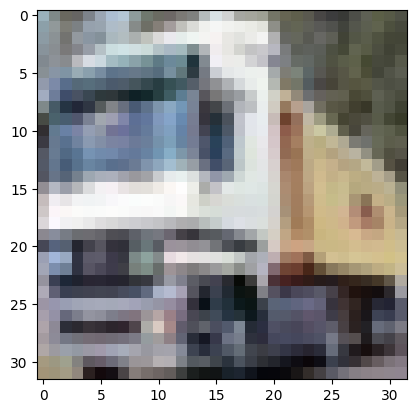

In [9]:
plt.imshow(image)

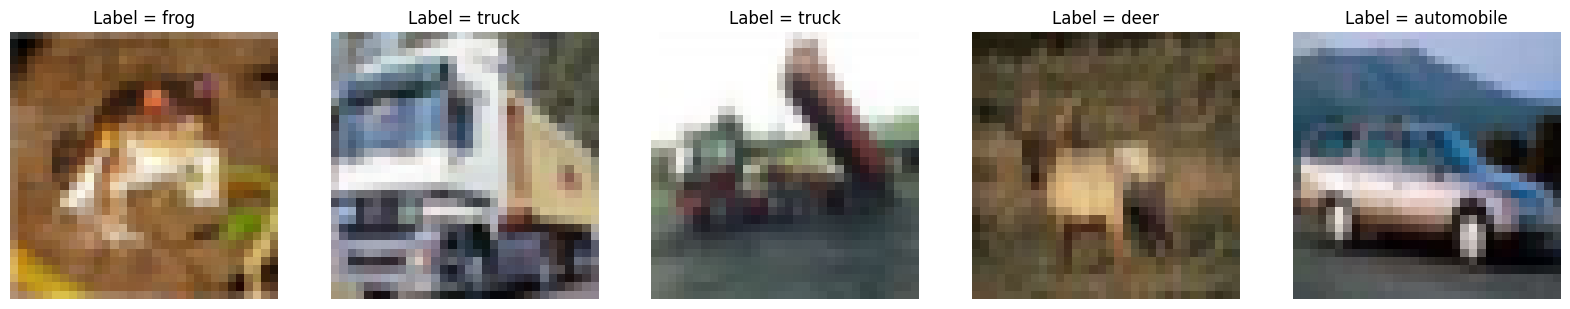

In [10]:
# Hiển thị 5 ảnh trong bộ DL
fig, axs = plt.subplots(1,5, figsize = (20,4))
for i in range(5):
    axs[i].imshow(TrainSet[i][0])
    axs[i].set_title(f"Label = {TrainSet.classes[TrainSet[i][1]]}")
    axs[i].axis('off')

# Chuyển DL về dạng Tensor

In [11]:
TrainSet = CIFAR10(
    root=folder,
    train=True,
    download=True,
    transform= transforms.Compose([transforms.ToTensor(),])
)

In [12]:
_, labels = zip(*TrainSet)

# Tách DL thành tập trainset và Validationset

In [13]:
ValSize = 0.1

In [14]:
arr_idx = np.arange(len(labels))

In [15]:
train_idx, val_idx = train_test_split(arr_idx,test_size=ValSize,shuffle= True, random_state=42, stratify=np.array(labels))

In [16]:
TrainSet= Subset(TrainSet,train_idx)

# Tiến hành chuẩn hóa DL bằng z-score

In [17]:
def compute_mean_std_image(datatset, channels: int = 1, batch_size = 1024):
    dataloader = DataLoader(datatset, shuffle=True, batch_size=batch_size)
    mean = torch.zeros(channels)
    std = torch.zeros(channels)
    total_sample = 0 
    for img, label in dataloader:
        BatchSize = img.shape[0]
        img = img.view(BatchSize, channels, -1)
        mean += torch.mean(img, dim =[0,2])*BatchSize
        std += torch.std(img, dim = [0,2])*BatchSize
        total_sample += BatchSize
    mean/= total_sample
    std/= total_sample
    return mean, std

In [18]:
# Tính mean và std của TrainSet đã được tách 
_mean, _std = compute_mean_std_image(TrainSet, channels=3)

In [19]:
print(_mean)
print(_std)

tensor([0.4911, 0.4821, 0.4464])
tensor([0.2468, 0.2434, 0.2615])


In [20]:
# chuẩn hóa DL của ảnh về dạng Normal distribution và thêm nhiễu cho DL train 
TrainSet = CIFAR10(
    root=folder,
    train=True,
    download=True,
    transform= transforms.Compose([transforms.ToTensor(),
                                   transforms.Normalize(mean=_mean, std=_std),
                                   transforms.RandomErasing(
                                       p=0.5, # xác suất một ảnh bị xóa 
                                       scale=(0.01, 0.3), # Tỷ diện tích bị xóa so với diện tích tổng thể ảnh gốc
                                       ratio=(1.0, 1.0), # Đây là hình gì
                                       value=0, # giá trị thay thế khi xóa
                                       inplace=True
                                   )
                                  ])
)

ValSet = CIFAR10(
    root=folder,
    train=True,
    download=True,
    transform= transforms.Compose([transforms.ToTensor(),
                                   transforms.Normalize(mean=_mean, std=_std),
                                  ])
)

C:\Anaconda\envs\study_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [21]:
TrainSet = Subset(TrainSet,train_idx)
ValSet = Subset(ValSet, val_idx)

In [22]:
len(TrainSet)

45000

In [23]:
TrainSet[0]

(tensor([[[-1.4972, -1.5290, -1.5608,  ..., -1.7673, -1.7673, -1.7197],
          [-1.3701, -1.5290, -1.5767,  ..., -1.7197, -1.7356, -1.7832],
          [-1.3384, -1.3384, -1.5290,  ..., -1.6561, -1.7356, -1.6879],
          ...,
          [ 0.0280,  0.0280, -0.0356,  ...,  0.2186,  0.2027,  0.1709],
          [-0.0197, -0.0197, -0.0038,  ...,  0.0280, -0.0197, -0.0833],
          [ 0.0756,  0.1233,  0.1551,  ...,  0.1551,  0.1233,  0.0597]],
 
         [[-1.2235, -1.3202, -1.4975,  ..., -1.6747, -1.6747, -1.6264],
          [-1.0946, -1.3686, -1.4652,  ..., -1.6264, -1.6425, -1.7069],
          [-1.0624, -1.0946, -1.3041,  ..., -1.5136, -1.5941, -1.6102],
          ...,
          [-0.1118, -0.1601, -0.2568,  ...,  0.0654,  0.0493,  0.0171],
          [-0.1601, -0.2085, -0.2246,  ..., -0.1279, -0.1762, -0.2407],
          [-0.0473, -0.0473, -0.0312,  ..., -0.0312, -0.0473, -0.1118]],
 
         [[-1.3921, -1.3771, -1.3471,  ..., -1.4970, -1.5120, -1.4670],
          [-1.3171, -1.4071,

In [24]:
BaseMLP??

Init signature: BaseMLP()
Source:        
class BaseMLP(ABC):
    r"""
    abstract class - Lớp trừu tượng - Tạo bộ khung, mẫu cho class BASEMLP

    All subclass should overwrite metthod 'predict' to get prediction of model throught
    logits = self.Forward().
    Subclass also should overwrite metthod 'get_accuracy' to get accuracy from 2 parameter logits and y
    Subclass also should overwrite metthod 'compute_loss' to get loss_value from self.criterion
    """


    def __init__(self):
        self.Layers = []
        self.model = None
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.criterion = None
    
    @abstractmethod
    def predict(self,X):
        pass
    @abstractmethod
    def get_accuracy(self,logits,y):
        pass
    @abstractmethod
    def compute_loss(self,logits, y):
        pass


    def Add_layer(self,layers):
        if not isinstance(layers, list):
            raise TypeError("layers must be a list")
        self.Layers.e

In [25]:
class BaseCNN(BaseMLP):
    # Kế thừa toàn bộ thuộc tính và phương thức của lớp MLP
    def __init__(self):
        super().__init__()
    
    def predict(self,X):
        with torch.no_grad():
            self.model.eval()
            X = X.to(self.device)
            logits = self.forward(X)
        return torch.argmax(logits, dim = 1)
    
    def get_accuracy(self, logits, y):
        try:
            return torch.mean((torch.argmax(logits, dim =1) == y).float())
        except:
            return torch.mean((torch.argmax(logits, dim =1) == torch.argmax(y, dim =1)).float())
    def compute_loss(self,logits,y):
        return self.criterion(logits,y)

In [26]:
CifaCNN = BaseCNN()

# Build Architecture of CNN for CIFA-10

In [27]:
# bock 1:
block1 = [
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding='same',stride=1),
    nn.ReLU(),
    nn.BatchNorm2d(num_features=32),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding='same', stride=1),
    nn.ReLU(),
    nn.BatchNorm2d(num_features=32),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(p=0.3)
]
CifaCNN.Add_layer(block1)

# block2
block2 = [
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same',stride=1),
    nn.ReLU(),
    nn.BatchNorm2d(num_features=64),
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding='same', stride=1),
    nn.ReLU(),
    nn.BatchNorm2d(num_features=64),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(p=0.3)
]
CifaCNN.Add_layer(block2)

#block3
block3 = [
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding='same',stride=1),
    nn.ReLU(),
    nn.BatchNorm2d(num_features=128),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding='same', stride=1),
    nn.ReLU(),
    nn.BatchNorm2d(num_features=128),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding='same', stride=1),
    nn.ReLU(),
    nn.BatchNorm2d(num_features=128),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(p=0.3)
]
CifaCNN.Add_layer(block3)

# block4
block4 = [
    nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding='same',stride=1),
    nn.ReLU(),
    nn.BatchNorm2d(num_features=256),
    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding='same', stride=1),
    nn.ReLU(),
    nn.BatchNorm2d(num_features=256),
    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding='same', stride=1),
    nn.ReLU(),
    nn.BatchNorm2d(num_features=256),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(p=0.3)
]
CifaCNN.Add_layer(block4)

# Block5
block5 = [
    nn.Flatten(),
    nn.Linear(in_features=256*2*2, out_features= 512, bias = True),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(in_features=512, out_features=10, bias=True)
]
CifaCNN.Add_layer(block5)

In [28]:
summary(CifaCNN.model, input_size=(3,32,32), batch_size=1024, device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [1024, 32, 32, 32]             896
              ReLU-2         [1024, 32, 32, 32]               0
       BatchNorm2d-3         [1024, 32, 32, 32]              64
            Conv2d-4         [1024, 32, 32, 32]           9,248
              ReLU-5         [1024, 32, 32, 32]               0
       BatchNorm2d-6         [1024, 32, 32, 32]              64
         MaxPool2d-7         [1024, 32, 16, 16]               0
           Dropout-8         [1024, 32, 16, 16]               0
            Conv2d-9         [1024, 64, 16, 16]          18,496
             ReLU-10         [1024, 64, 16, 16]               0
      BatchNorm2d-11         [1024, 64, 16, 16]             128
           Conv2d-12         [1024, 64, 16, 16]          36,928
             ReLU-13         [1024, 64, 16, 16]               0
      BatchNorm2d-14         [1024, 64,

# khởi tạo toàn bộ trọng số của mô hình bằng phương pháp kaming_He_init

In [29]:
for layer in CifaCNN.model:
    if isinstance(layer, nn.Conv2d) or isinstance(layer, nn.Linear):
        init.kaiming_normal_(layer.weight)
        init.zeros_(layer.bias)

# Using Regularization to reduce Overfitting of Model

In [30]:
optimizer = torch.optim.Adam(CifaCNN.model.parameters(), lr=0.001, weight_decay=0.001)

In [31]:
CifaCNN.fit(dataset=TrainSet, val_dataset=ValSet, n_epochs=30, batch_size=1024, verbose=2, is_shuffle=True, criterion='CE', optimizer=optimizer)

  0%|                                                                                           | 0/30 [00:00<?, ?it/s]

Epoch [   1/30]


  3%|██▊                                                                                | 1/30 [00:33<16:10, 33.46s/it]

Loss = 2.4857 - Accuracy = 0.2158 - Loss_Validation = 2.0724 - Accracy_Validation = 0.2434
Epoch [   2/30]


  7%|█████▌                                                                             | 2/30 [01:02<14:23, 30.85s/it]

...

Loss = 0.2379 - Accuracy = 0.9182 - Loss_Validation = 0.8060 - Accracy_Validation = 0.7704
Epoch [  29/30]


 97%|███████████████████████████████████████████████████████████████████████████████▎  | 29/30 [14:05<00:28, 28.88s/it]

Loss = 0.2266 - Accuracy = 0.9218 - Loss_Validation = 0.8160 - Accracy_Validation = 0.7682
Epoch [  30/30]


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [14:34<00:00, 29.13s/it]

Loss = 0.2193 - Accuracy = 0.9248 - Loss_Validation = 0.8343 - Accracy_Validation = 0.7658
